In [2]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import bisect

In [3]:
# ============================
# Constants
# ============================

kpcincm = 3.0857e21       # cm / kpc
MSuninGeV = 1.115e57      # GeV
rSun = 8.277              # kpc
rhoSun = 0.4              # GeV / cm^3
r200 = 220.2              # kpc

In [4]:
# ============================
# DM profile
# ============================

def rhogNFW(r, rhos, rs, gamma):
    x = r / rs
    return rhos / (x**gamma * (1 + x)**(3 - gamma))

def rhocNFWt(r, rhos, rs, rc, n, delta, rt):
    f = np.tanh(r/rc)
    MNFW = 4*np.pi * rhos * rs**3 * (np.log(1+r/rs) - r/rs/(1+r/rs))
    rhocNFW = f**n * rhogNFW(r, rhos, rs, 1.0) + n*f**(n-1) * (1 - f**2) / (4*np.pi*r**2*rc) * MNFW
    if r <= rt:
        return rhocNFW
    else:
        return rhocNFW * (r/rt)**-delta

In [5]:
# ============================
# Local DM density constraint
# ============================

def rhos(rho_func, rs, *args):
    return rhoSun / rho_func(rSun, 1.0, rs, *args)

# ============================
# Halo mass constraint
# ============================

def DeltaM200(rho_func, rs, *args):
    rhos_val = rhos(rho_func, rs, *args)

    def integrand(r):
        return r**2 * rho_func(r, rhos_val, rs, *args)
    
    M200 = 4 * np.pi * quad(integrand, 0, r200, epsrel=1e-5)[0]
    M200 *= kpcincm**3 / MSuninGeV
    return M200 - 1e12

def rs(rho_func, *args):
    return bisect(lambda rs, *args: DeltaM200(rho_func, rs, *args), 0.1, 50, args=(args), xtol=1e-6)

In [6]:
# ============================
# Line-of-sight integral
# ============================

def J_los(theta, rho_func, rhos, rs, *args, D=rSun):

    def integrand(s):
        r = np.sqrt(D**2 + s**2 - 2*s*D*np.cos(theta))
        return rho_func(r, rhos, rs, *args)**2
    
    return kpcincm * quad(integrand, 0, 400, epsrel=1e-4)[0]

# ============================
# J-factor
# ============================

def Jfactor(thetamax, rho_func, rhos, rs, *args, D=rSun):

    def integrand(theta):
        return J_los(theta, rho_func, rhos, rs, *args, D=D) * 2*np.pi*np.sin(theta)

    return quad(integrand, 0, thetamax, epsrel=1e-4)[0]

# ============================
# Compute J-factor
# ============================

thetamax = np.radians(10) # degrees

gamma = 1.26
rsVal = rs(rhogNFW, gamma)
rhosVal = rhos(rhogNFW, rsVal, gamma)
print("J-factor gNFW, gamma=1.26:", Jfactor(thetamax, rhogNFW, rhosVal, rsVal, gamma), 'GeV2/cm5')

/tmp/ipykernel_104314/1762793931.py:11: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return kpcincm * quad(integrand, 0, 400, epsrel=1e-4)[0]


J-factor gNFW, gamma=1.26: 1.836875051413006e+23 GeV2/cm5


### Question 1.1.1 (Section 1.1, Question 1)
Compute the J-factor within $20^\circ$ from the Galactic Center for a gNFW profile with:
- $\gamma = 1.0$ (standard NFW)
- $\gamma = 1.26$ (cuspy gNFW)

In [7]:
# Solution 1.1.1
thetamax = np.radians(20)

for gamma in [1.0, 1.26]:
    rsVal = rs(rhogNFW, gamma)
    rhosVal = rhos(rhogNFW, rsVal, gamma)
    J20 = Jfactor(thetamax, rhogNFW, rhosVal, rsVal, gamma)
    print(f"gamma={gamma:.2f} -> J(20 deg) = {J20:.6e} GeV2/cm5")


gamma=1.00 -> J(20 deg) = 9.925038e+22 GeV2/cm5


/tmp/ipykernel_104314/1762793931.py:11: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return kpcincm * quad(integrand, 0, 400, epsrel=1e-4)[0]


gamma=1.26 -> J(20 deg) = 2.303914e+23 GeV2/cm5


### Question 1.1.2 (Section 1.1, Question 1)
Can the two constraints (local density and halo mass) fix the scale parameters of the isothermal profile?
Then, fixing $r_s = 4$ kpc, verify that the J-factor in the same ROI is of order $10^{22}$ GeV$^2$/cm$^5$.

In [8]:
# Solution 1.1.2
def rhoiso(r, rhos, rs):
    return rhos / (1 + (r/rs)**2)

# Check whether the halo-mass constraint can be solved for rs (with rhoSun fixed)
for rs_try in [0.1, 1.0, 4.0, 10.0, 50.0]:
    print(f"DeltaM200(rs={rs_try:>4.1f} kpc) = {DeltaM200(rhoiso, rs_try):.6e} Msun")

try:
    rs_iso = rs(rhoiso)
    rhos_iso = rhos(rhoiso, rs_iso)
    print(f"Solved isothermal parameters: rs={rs_iso:.6f} kpc, rhos={rhos_iso:.6e} GeV/cm^3")
except ValueError as e:
    print("No rs root found in the default bracket [0.1, 50] kpc -> the two constraints cannot be simultaneously satisfied for this isothermal setup.")
    print("Reason from solver:", e)

# Now fix rs = 4 kpc and only impose local density normalization
rs_iso_fixed = 4.0
rhos_iso_fixed = rhos(rhoiso, rs_iso_fixed)
J20_iso_fixed = Jfactor(np.radians(20), rhoiso, rhos_iso_fixed, rs_iso_fixed)
print(f"With rs=4 kpc: rhos={rhos_iso_fixed:.6e} GeV/cm^3, J(20 deg)={J20_iso_fixed:.6e} GeV2/cm5")


DeltaM200(rs= 0.1 kpc) = 9.969761e+11 Msun
DeltaM200(rs= 1.0 kpc) = 1.012856e+12 Msun
DeltaM200(rs= 4.0 kpc) = 1.395246e+12 Msun
DeltaM200(rs=10.0 kpc) = 3.574226e+12 Msun
DeltaM200(rs=50.0 kpc) = 5.099113e+13 Msun
No rs root found in the default bracket [0.1, 50] kpc -> the two constraints cannot be simultaneously satisfied for this isothermal setup.
Reason from solver: f(a) and f(b) must have different signs
With rs=4 kpc: rhos=2.112718e+00 GeV/cm^3, J(20 deg)=2.336308e+22 GeV2/cm5


### Question 1.1.3 (Section 1.1, Question 1)
Plot a dimensionless line-of-sight J-factor and D-factor versus $\theta$ (no integration over ROI), using the classic NFW profile ($\gamma=1$).

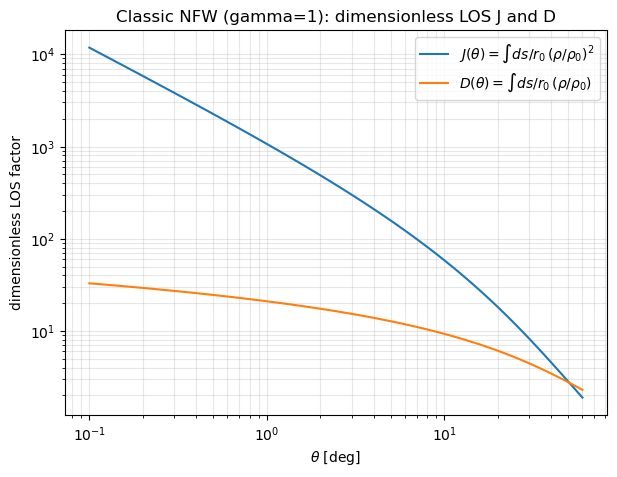

Used NFW parameters: rs=13.6305 kpc, rhos=6.2746e-01 GeV/cm^3, rho0=0.4, r0=8.277 kpc


In [9]:
# Solution 1.1.3
import matplotlib.pyplot as plt

# Dimensionless LOS factors (professor's convention)
# J(theta) = ∫ (ds/r0) * (rho/rho0)^2
# D(theta) = ∫ (ds/r0) * (rho/rho0)
rho0 = 0.4   # GeV/cm^3
r0 = rSun    # kpc (use r0 = 8.277 if your class convention explicitly asks it)

def J_theta_dim(theta, rho_func, rhos, rs, *args, D=rSun, r0=r0, rho0=rho0):
    def integrand(s):
        r = np.sqrt(D**2 + s**2 - 2*s*D*np.cos(theta))
        return (rho_func(r, rhos, rs, *args) / rho0)**2 / r0
    return quad(integrand, 0, 400, epsrel=1e-4)[0]

def D_theta_dim(theta, rho_func, rhos, rs, *args, D=rSun, r0=r0, rho0=rho0):
    def integrand(s):
        r = np.sqrt(D**2 + s**2 - 2*s*D*np.cos(theta))
        return (rho_func(r, rhos, rs, *args) / rho0) / r0
    return quad(integrand, 0, 400, epsrel=1e-4)[0]

# Classic NFW
gamma = 1.0
rsVal = rs(rhogNFW, gamma)
rhosVal = rhos(rhogNFW, rsVal, gamma)

theta_deg = np.logspace(-1, np.log10(60), 120)
theta_rad = np.radians(theta_deg)

J_dim = np.array([J_theta_dim(t, rhogNFW, rhosVal, rsVal, gamma) for t in theta_rad])
D_dim = np.array([D_theta_dim(t, rhogNFW, rhosVal, rsVal, gamma) for t in theta_rad])

plt.figure(figsize=(7,5))
plt.loglog(theta_deg, J_dim, label=r'$J(\theta) = \int ds/r_0 \,(\rho/\rho_0)^2$')
plt.loglog(theta_deg, D_dim, label=r'$D(\theta) = \int ds/r_0 \,(\rho/\rho_0)$')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('dimensionless LOS factor')
plt.title('Classic NFW (gamma=1): dimensionless LOS J and D')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

print(f'Used NFW parameters: rs={rsVal:.4f} kpc, rhos={rhosVal:.4e} GeV/cm^3, rho0={rho0}, r0={r0} kpc')
